# H1. 자치구별 상권 유형에 따른 점포 순감소 차이 분석

### 분석 가설
동일 서비스업종이라도 자치구별 상권 유형에 따라 다음 분기 점포 순감소 여부에 차이가 있을 것이다.

### 분석 기간
2023년 1분기 ~ 2026년 1분기

In [212]:
import pandas as pd

## 0. 라이브러리 불러오기
데이터 불러오기 및 전처리를 위해 pandas를 사용한다.

In [213]:
import os

os.listdir()

['.git',
 'H1_분석.ipynb',
 '서울상권_프로젝트A_심화설계.md',
 '서울시 상권분석서비스(영역-상권).csv',
 '서울시 상권분석서비스(점포-상권).csv',
 '서울시 상권분석서비스(점포-상권)_2024년.csv',
 '서울시_상권분석서비스(점포-상권)_2023년.csv']

In [214]:
df_2023 = pd.read_csv(
    "서울시_상권분석서비스(점포-상권)_2023년.csv",
    encoding="cp949"
)

df_2023.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수
0,20231,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,9,1,0,0,1
1,20231,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0
2,20231,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,3,0,0,0,0,0
3,20231,A,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,2,3,0,0,0,0,1
4,20231,A,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,1,0,0,0,0,0


In [215]:
df_2024 = pd.read_csv(
    "서울시 상권분석서비스(점포-상권)_2024년.csv",
    encoding="cp949"
)

df_2024.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수
0,20241,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,0,0,0,0,1
1,20241,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0
2,20241,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,2,2,0,0,50,1,0
3,20241,A,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,4,5,20,1,0,0,1
4,20241,A,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,1,0,0,0,0,0


In [216]:
df_recent = pd.read_csv(
    "서울시 상권분석서비스(점포-상권).csv",
    encoding="cp949"
)

df_recent.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,전체_점포_수,일반_점포_수,프랜차이즈_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수
0,20261,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300043,전자상거래업,3,3,0,0,0,0,0
1,20261,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300035,인테리어,2,2,0,0,0,0,0
2,20261,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300029,애완동물,1,1,0,0,0,0,0
3,20261,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300027,섬유제품,1,1,0,0,0,100,1
4,20261,R,전통시장,3130327,"평화시장(남평화시장, 제일평화시장, 신평화패션타운)",CS300024,운동/경기용품,5,5,0,0,0,0,0


## 1. 점포-상권 데이터 불러오기 및 통합

서울시 상권분석서비스의 2023년, 2024년, 2025~2026년 점포-상권 데이터를 불러왔다.

연도별 파일의 컬럼 구성을 확인한 결과, 점포 관련 컬럼명이 변경되어 있어 동일한 의미의 변수를 기준으로 컬럼명을 통일하였다.

- 2023~2024년 `점포_수` ↔ 최근 데이터 `일반_점포_수`
- 2023~2024년 `유사_업종_점포_수` ↔ 최근 데이터 `전체_점포_수`

분기별 점포 수를 동일한 기준으로 비교하기 위해 최근 데이터의 `일반_점포_수`를 `점포_수`로, `전체_점포_수`를 `유사_업종_점포_수`로 변경하였다.

이후 세 데이터를 `concat`하여 2023년 1분기부터 2026년 1분기까지 하나의 데이터프레임으로 통합하였다.

In [217]:
print(df_2023.columns.tolist())
print(df_2024.columns.tolist())
print(df_recent.columns.tolist())

['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '점포_수', '유사_업종_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수', '프랜차이즈_점포_수']
['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드', '서비스_업종_코드_명', '전체_점포_수', '일반_점포_수', '프랜차이즈_점포_수', '개업_율', '개업_점포_수', '폐업_률', '폐업_점포_수']


In [218]:
df_recent = df_recent.rename(columns={
    "일반_점포_수": "점포_수",
    "전체_점포_수": "유사_업종_점포_수"
})

In [219]:
df_all = pd.concat(
    [df_2023, df_2024, df_recent],
    ignore_index=True
)

df_all.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수
0,20231,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,9,1,0,0,1
1,20231,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0
2,20231,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,3,0,0,0,0,0
3,20231,A,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,2,3,0,0,0,0,1
4,20231,A,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,1,0,0,0,0,0


### 데이터 기간 확인

통합 데이터에 포함된 분기를 확인하여 분석 기간이 연속적으로 구성되어 있는지 점검한다.

In [220]:
print(df_all.shape)
print(df_all["기준_년분기_코드"].unique())

(995377, 14)
[20231 20232 20233 20234 20241 20242 20243 20244 20261 20254 20253 20252
 20251]


In [221]:
sorted(df_all["기준_년분기_코드"].unique())

[np.int64(20231),
 np.int64(20232),
 np.int64(20233),
 np.int64(20234),
 np.int64(20241),
 np.int64(20242),
 np.int64(20243),
 np.int64(20244),
 np.int64(20251),
 np.int64(20252),
 np.int64(20253),
 np.int64(20254),
 np.int64(20261)]

- 분석 기간: 2023년 1분기 ~ 2026년 1분기
- 총 13개 분기
- 통합 데이터 크기: 995,377행 × 14열
- 분석 기간 내 분기 누락 없음

## 2. 통합 데이터 구조 확인

통합된 데이터의 기본 구조와 중복 여부를 확인한다.

분기별·상권별·서비스업종별 점포 수를 비교해야 하므로,
`기준_년분기_코드 + 상권_코드 + 서비스_업종_코드` 조합이 하나의 관측치를 구분할 수 있는지 확인한다.

In [222]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 995377 entries, 0 to 995376
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   기준_년분기_코드    995377 non-null  int64
 1   상권_구분_코드     995377 non-null  str  
 2   상권_구분_코드_명   995377 non-null  str  
 3   상권_코드        995377 non-null  int64
 4   상권_코드_명      995377 non-null  str  
 5   서비스_업종_코드    995377 non-null  str  
 6   서비스_업종_코드_명  995377 non-null  str  
 7   점포_수         995377 non-null  int64
 8   유사_업종_점포_수   995377 non-null  int64
 9   개업_율         995377 non-null  int64
 10  개업_점포_수      995377 non-null  int64
 11  폐업_률         995377 non-null  int64
 12  폐업_점포_수      995377 non-null  int64
 13  프랜차이즈_점포_수   995377 non-null  int64
dtypes: int64(9), str(5)
memory usage: 106.3 MB


In [223]:
key_cols = [
    "기준_년분기_코드",
    "상권_코드",
    "서비스_업종_코드"
]

df_all.duplicated(subset=key_cols).sum()

np.int64(0)

### 데이터 구조 확인 결과

- 전체 데이터: 995,377행 × 14열
- 분석 기간: 2023년 1분기 ~ 2026년 1분기 (총 13개 분기)
- `기준_년분기_코드 + 상권_코드 + 서비스_업종_코드` 기준 중복: 0건
- 순감소 여부 계산에 필요한 `점포_수`에는 결측치가 없음


In [224]:
df_area = pd.read_csv(
    "서울시 상권분석서비스(영역-상권).csv",
    encoding="cp949"
)

df_area.head()

,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,엑스좌표_값,와이좌표_값,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,영역_면적
0,A,골목상권,3110055,황학동벼룩시장,201642,452260,11140,중구,11140670,황학동,27575
1,A,골목상권,3110008,배화여자대학교(박노수미술관),197093,453418,11110,종로구,11110515,청운효자동,149264
2,A,골목상권,3110009,자하문터널,196991,455057,11110,종로구,11110550,부암동,178306
3,A,골목상권,3110010,평창동서측,197064,456643,11110,종로구,11110560,평창동,369415
4,A,골목상권,3110017,정독도서관,198581,453781,11110,종로구,11110600,가회동,83855


In [225]:
df_area.columns.tolist()


['상권_구분_코드',
 '상권_구분_코드_명',
 '상권_코드',
 '상권_코드_명',
 '엑스좌표_값',
 '와이좌표_값',
 '자치구_코드',
 '자치구_코드_명',
 '행정동_코드',
 '행정동_코드_명',
 '영역_면적']

In [226]:
area_key = df_area[
    ["상권_코드", "자치구_코드", "자치구_코드_명"]
].drop_duplicates()

area_key.head()

,상권_코드,자치구_코드,자치구_코드_명
0,3110055,11140,중구
1,3110008,11110,종로구
2,3110009,11110,종로구
3,3110010,11110,종로구
4,3110017,11110,종로구


In [227]:
area_key["상권_코드"].duplicated().sum()

np.int64(0)

### 자치구 정보 결합

`상권_코드`가 영역-상권 데이터에서 중복되지 않는 것을 확인한 뒤,
점포-상권 데이터에 자치구 정보를 결합하였다.

In [228]:
df_all = df_all.merge(
    area_key,
    on="상권_코드",
    how="left"
)

df_all.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,자치구_코드,자치구_코드_명
0,20231,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,9,1,0,0,1,11110,종로구
1,20231,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0,11110,종로구
2,20231,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,3,0,0,0,0,0,11110,종로구
3,20231,A,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,2,3,0,0,0,0,1,11110,종로구
4,20231,A,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,1,0,0,0,0,0,11110,종로구


In [229]:
print(df_all.shape)
print(df_all["자치구_코드_명"].isna().sum())

(995377, 16)
0


In [230]:
df_h1 = df_all[
    [
        "기준_년분기_코드",
        "자치구_코드_명",
        "상권_구분_코드_명",
        "상권_코드",
        "상권_코드_명",
        "서비스_업종_코드",
        "서비스_업종_코드_명",
        "점포_수",
        "개업_율",
        "개업_점포_수",
        "폐업_률",
        "폐업_점포_수"
    ]
].copy()

df_h1.head()

,기준_년분기_코드,자치구_코드_명,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수
0,20231,종로구,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,9,1,0,0
1,20231,종로구,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,0,0,0,0
2,20231,종로구,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,0,0,0,0
3,20231,종로구,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,2,0,0,0,0
4,20231,종로구,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,0,0,0,0


## 4. H1 분석용 변수 정리

H1 분석에 필요한 분기, 자치구, 상권유형, 서비스업종, 점포 수를 중심으로 변수를 정리한다.

In [231]:
df_h1 = df_all[
    [
        "기준_년분기_코드",
        "자치구_코드_명",
        "상권_구분_코드_명",
        "상권_코드",
        "상권_코드_명",
        "서비스_업종_코드",
        "서비스_업종_코드_명",
        "점포_수",
        "개업_율",
        "개업_점포_수",
        "폐업_률",
        "폐업_점포_수"
    ]
].copy()

df_h1.head()

,기준_년분기_코드,자치구_코드_명,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수
0,20231,종로구,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,9,1,0,0
1,20231,종로구,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,0,0,0,0
2,20231,종로구,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,0,0,0,0
3,20231,종로구,골목상권,3110001,이북5도청사,CS100009,호프-간이주점,2,0,0,0,0
4,20231,종로구,골목상권,3110001,이북5도청사,CS100010,커피-음료,1,0,0,0,0


### 상권 유형 및 서비스업종 확인

분석에 앞서 상권 유형과 서비스업종이 어떤 범주로 구성되어 있는지 확인한다.

In [232]:
df_h1["상권_구분_코드_명"].value_counts()

상권_구분_코드_명
골목상권    616014
발달상권    233207
전통시장    139405
관광특구      6751
Name: count, dtype: int64

In [233]:
print("서비스업종 수:", df_h1["서비스_업종_코드_명"].nunique())

서비스업종 수: 100


In [234]:
df_h1["서비스_업종_코드_명"].value_counts()

서비스_업종_코드_명
한식음식점     20474
부동산중개업    20114
커피-음료     19757
일반의류      19321
미용실       19179
          ...  
한복점        1638
볼링장        1151
DVD방       1076
고시원        1031
중고가구        910
Name: count, Length: 100, dtype: int64

## 5. 다음 분기 점포 순감소 여부 생성

동일한 상권·서비스업종의 점포 수를 분기 순서대로 비교하기 위해
상권과 서비스업종별로 데이터를 묶고 분기 순으로 정렬한다.

이후 다음 분기의 점포 수가 현재 분기보다 감소한 경우를 `1`,
감소하지 않은 경우를 `0`으로 정의한다.

In [235]:
df_h1 = df_h1.sort_values(
    ["상권_코드", "서비스_업종_코드", "기준_년분기_코드"]
).reset_index(drop=True)

df_h1.head(15)

,기준_년분기_코드,자치구_코드_명,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수
0,20231,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,117,4,5,4,5
1,20232,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,119,2,3,1,1
2,20233,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,117,3,4,4,5
3,20234,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,118,2,2,1,1
4,20241,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,122,8,10,3,4
5,20242,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,126,9,12,6,8
6,20243,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,128,8,11,4,6
7,20244,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,132,5,7,3,4
8,20251,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,135,5,8,3,5
9,20252,용산구,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,134,3,5,5,7


### 다음 분기 점포 수 생성

같은 상권·같은 서비스업종 안에서 바로 다음 분기의 점포 수를 가져와,
현재 분기 점포 수와 비교할 수 있도록 한다.

In [236]:
df_h1["다음_분기_점포_수"] = (
    df_h1
    .groupby(["상권_코드", "서비스_업종_코드"])["점포_수"]
    .shift(-1)
)

df_h1[
    [
        "기준_년분기_코드",
        "상권_코드",
        "서비스_업종_코드_명",
        "점포_수",
        "다음_분기_점포_수"
    ]
].head(15)

,기준_년분기_코드,상권_코드,서비스_업종_코드_명,점포_수,다음_분기_점포_수
0,20231,3001491,한식음식점,117,119.0
1,20232,3001491,한식음식점,119,117.0
2,20233,3001491,한식음식점,117,118.0
3,20234,3001491,한식음식점,118,122.0
4,20241,3001491,한식음식점,122,126.0
5,20242,3001491,한식음식점,126,128.0
6,20243,3001491,한식음식점,128,132.0
7,20244,3001491,한식음식점,132,135.0
8,20251,3001491,한식음식점,135,134.0
9,20252,3001491,한식음식점,134,137.0


In [237]:
df_h1["다음_분기_코드"] = (
    df_h1
    .groupby(["상권_코드", "서비스_업종_코드"])["기준_년분기_코드"]
    .shift(-1)
)

df_h1[
    [
        "기준_년분기_코드",
        "다음_분기_코드",
        "상권_코드",
        "서비스_업종_코드_명"
    ]
].head(20)

,기준_년분기_코드,다음_분기_코드,상권_코드,서비스_업종_코드_명
0,20231,20232.0,3001491,한식음식점
1,20232,20233.0,3001491,한식음식점
2,20233,20234.0,3001491,한식음식점
3,20234,20241.0,3001491,한식음식점
4,20241,20242.0,3001491,한식음식점
5,20242,20243.0,3001491,한식음식점
6,20243,20244.0,3001491,한식음식점
7,20244,20251.0,3001491,한식음식점
8,20251,20252.0,3001491,한식음식점
9,20252,20253.0,3001491,한식음식점


### 다음 분기 순감소 여부 생성

현재 분기의 점포 수와 다음 분기의 점포 수를 비교하여,
다음 분기 점포 수가 감소한 경우 `1`, 감소하지 않은 경우 `0`으로 정의한다.

단, 다음 분기 데이터가 없는 경우에는 순감소 여부를 판단할 수 없으므로 결측값으로 처리한다.

In [238]:
import numpy as np

df_h1["다음_분기_순감소"] = np.where(
    df_h1["다음_분기_점포_수"].isna(),
    np.nan,
    (df_h1["다음_분기_점포_수"] < df_h1["점포_수"]).astype(int)
)

In [239]:
quarter_order = [
    20231, 20232, 20233, 20234,
    20241, 20242, 20243, 20244,
    20251, 20252, 20253, 20254,
    20261
]

next_quarter = {
    quarter_order[i]: quarter_order[i + 1]
    for i in range(len(quarter_order) - 1)
}

df_h1["정상_다음_분기"] = df_h1["기준_년분기_코드"].map(next_quarter)

wrong_gap = (
    df_h1["다음_분기_코드"].notna()
    & (df_h1["다음_분기_코드"] != df_h1["정상_다음_분기"])
)


print("분기를 건너뛴 관측치:", wrong_gap.sum())

분기를 건너뛴 관측치: 566


In [240]:
# 연속된 다음 분기만 남기기
df_h1.loc[wrong_gap, "다음_분기_순감소"] = np.nan

print("분기 건너뛰기 제외:", wrong_gap.sum())
print("\n다음_분기_순감소 분포")
print(df_h1["다음_분기_순감소"].value_counts(dropna=False))

print(
    "\n분석 가능 데이터:",
    df_h1["다음_분기_순감소"].notna().sum()
)

분기 건너뛰기 제외: 566

다음_분기_순감소 분포
다음_분기_순감소
0.0    842509
NaN     82578
1.0     70290
Name: count, dtype: int64

분석 가능 데이터: 912799


In [241]:
df_h1[
    [
        "기준_년분기_코드",
        "상권_코드_명",
        "서비스_업종_코드_명",
        "점포_수",
        "다음_분기_점포_수",
        "다음_분기_순감소"
    ]
].head(20)

,기준_년분기_코드,상권_코드_명,서비스_업종_코드_명,점포_수,다음_분기_점포_수,다음_분기_순감소
0,20231,이태원 관광특구,한식음식점,117,119.0,0.0
1,20232,이태원 관광특구,한식음식점,119,117.0,1.0
2,20233,이태원 관광특구,한식음식점,117,118.0,0.0
3,20234,이태원 관광특구,한식음식점,118,122.0,0.0
4,20241,이태원 관광특구,한식음식점,122,126.0,0.0
5,20242,이태원 관광특구,한식음식점,126,128.0,0.0
6,20243,이태원 관광특구,한식음식점,128,132.0,0.0
7,20244,이태원 관광특구,한식음식점,132,135.0,0.0
8,20251,이태원 관광특구,한식음식점,135,134.0,1.0
9,20252,이태원 관광특구,한식음식점,134,137.0,0.0


In [242]:
df_h1["다음_분기_순감소"].value_counts(dropna=False)

다음_분기_순감소
0.0    842509
NaN     82578
1.0     70290
Name: count, dtype: int64

In [243]:
df_h1.loc[
    df_h1["다음_분기_순감소"].isna(),
    "기준_년분기_코드"
].value_counts().sort_index()

기준_년분기_코드
20231      588
20232      537
20233      533
20234      477
20241      651
20242      596
20243      559
20244      467
20251      603
20252      539
20253      594
20254      462
20261    75972
Name: count, dtype: int64

In [244]:
(df_h1["점포_수"] == 0).value_counts()

점포_수
False    960553
True      34824
Name: count, dtype: int64

In [245]:
df_h1[
    (df_h1["다음_분기_순감소"].isna()) &
    (df_h1["기준_년분기_코드"] != 20261)
][
    [
        "기준_년분기_코드",
        "자치구_코드_명",
        "상권_코드",
        "상권_코드_명",
        "서비스_업종_코드",
        "서비스_업종_코드_명",
        "점포_수"
    ]
].head(20)

,기준_년분기_코드,자치구_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수
231,20253,용산구,3001491,이태원 관광특구,CS200009,동물병원,0
1755,20244,중구,3001492,명동 남대문 북창동 다동 무교동 관광특구,CS200046,의류임대,0
2228,20241,중구,3001492,명동 남대문 북창동 다동 무교동 관광특구,CS300039,모터사이클및부품,0
3000,20253,중구,3001493,동대문패션타운 관광특구,CS300005,주류도매,0
3384,20243,중구,3001493,동대문패션타운 관광특구,CS300037,중고차판매,0
3733,20253,종로구,3001494,종로?청계 관광특구,CS200014,회계사사무소,0
5080,20244,송파구,3001495,잠실 관광특구,CS200026,자동차미용,0
6159,20241,강남구,3001496,강남 마이스 관광특구,CS200026,자동차미용,0
6397,20243,강남구,3001496,강남 마이스 관광특구,CS300008,수산물판매,0
6676,20242,강남구,3001496,강남 마이스 관광특구,CS300033,철물점,0


In [246]:
df_h1.loc[
    (df_h1["다음_분기_순감소"].isna()) &
    (df_h1["기준_년분기_코드"] != 20261),
    "점포_수"
].value_counts()

점포_수
0    6541
1      64
2       1
Name: count, dtype: int64

In [247]:
weird = df_h1[
    (df_h1["다음_분기_순감소"].isna()) &
    (df_h1["기준_년분기_코드"] != 20261) &
    (df_h1["점포_수"] > 0)
]

weird[
    [
        "기준_년분기_코드",
        "자치구_코드_명",
        "상권_코드",
        "상권_코드_명",
        "서비스_업종_코드",
        "서비스_업종_코드_명",
        "점포_수"
    ]
].head(20)

,기준_년분기_코드,자치구_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수
24425,20254,중구,3110043,충무초등학교,CS200002,외국어학원,1
71245,20243,성동구,3110130,답십리역 6번,CS200038,독서실,1
94955,20244,광진구,3110165,국립정신건강센터,CS300036,조명용품,1
97130,20252,광진구,3110168,대원고등학교,CS300033,철물점,1
106178,20251,동대문구,3110184,용두사거리,CS300029,애완동물,1
108699,20252,동대문구,3110189,제기동역 1번,CS200043,건축물청소,1
113576,20254,동대문구,3110199,홍릉시장,CS300026,완구,1
124947,20254,동대문구,3110220,외대앞역 1번,CS300029,애완동물,1
126323,20254,동대문구,3110225,촬영소사거리,CS100005,제과점,1
136166,20253,중랑구,3110241,먹골역 5번,CS200013,기타법무서비스,1


### 다음 분기 관측 불가 데이터 처리

다음 분기 점포 수를 확인할 수 없는 관측치는 순감소 여부를 판단할 수 없으므로 분석 대상에서 제외한다.

대부분은 현재 점포 수가 0인 관측치였으며, 일부 점포가 존재하는 경우도 확인되었으나 데이터만으로 폐업·누락 등의 원인을 구분할 수 없어 임의로 순감소 여부를 부여하지 않았다.

## 6. 최종 분석 데이터 구성

다음 분기 점포 수가 확인되는 관측치만 사용하여 H1 분석용 데이터를 구성한다.

다음 분기 정보가 없는 경우에는 점포 순감소 여부를 판단할 수 없으므로 분석 대상에서 제외한다.

In [248]:
df_model = df_h1[
    df_h1["다음_분기_순감소"].notna()
].copy()

print("분석 데이터 수:", len(df_model))

df_model["다음_분기_순감소"].value_counts()

분석 데이터 수: 912799


다음_분기_순감소
0.0    842509
1.0     70290
Name: count, dtype: int64

In [249]:
df_model["다음_분기_순감소"].value_counts(normalize=True) * 100

다음_분기_순감소
0.0    92.29951
1.0     7.70049
Name: proportion, dtype: float64

## 7. 상권 유형별 점포 순감소 비율 확인

상권 유형에 따라 다음 분기 점포 순감소 비율에 차이가 있는지 확인한다.

먼저 골목상권, 발달상권, 전통시장, 관광특구별 순감소 비율을 비교한다.

In [250]:
decrease_by_type = (
    df_model
    .groupby("상권_구분_코드_명")["다음_분기_순감소"]
    .agg(["count", "sum", "mean"])
)

decrease_by_type["순감소율(%)"] = decrease_by_type["mean"] * 100

decrease_by_type

,count,sum,mean,순감소율(%)
상권_구분_코드_명,,,,
골목상권,564379,35494.0,0.062890,6.289036
관광특구,6222,1184.0,0.190293,19.029251
발달상권,214505,25223.0,0.117587,11.758700
전통시장,127693,8389.0,0.065697,6.569663


### 1차 확인 결과

상권 유형별 단순 순감소율을 비교한 결과, 관광특구(19.03%)와 발달상권(11.76%)에서 상대적으로 높은 순감소율이 나타났으며, 전통시장(6.57%)과 골목상권(6.29%)은 상대적으로 낮게 나타났다.

다만 이는 업종과 자치구의 차이를 고려하지 않은 단순 비교이므로,
상권 유형 자체의 차이라고 해석할 수는 없다.
이후 동일 업종 및 자치구 조건을 고려하여 차이를 추가로 확인한다.

## 8. 업종을 고려한 상권 유형별 순감소율 비교

앞선 분석에서는 상권 유형별 순감소율에 차이가 나타났다.

하지만 상권 유형마다 입점한 업종의 구성이 다를 수 있으므로,
단순 비교만으로 상권 유형 자체의 차이라고 판단하기 어렵다.

따라서 업종별로 나누어 동일 업종 내에서도
상권 유형에 따른 순감소율 차이가 나타나는지 확인한다.

In [251]:
print("업종 수:", df_model["서비스_업종_코드_명"].nunique())

print("\n업종별 데이터 수")
print(
    df_model["서비스_업종_코드_명"]
    .value_counts()
)

업종 수: 100

업종별 데이터 수
서비스_업종_코드_명
한식음식점     18883
부동산중개업    18559
커피-음료     18198
일반의류      17785
미용실       17685
          ...  
한복점        1482
볼링장        1061
고시원         939
중고가구        826
DVD방        823
Name: count, Length: 100, dtype: int64


In [252]:
# 업종 × 상권유형별 데이터 수 확인
업종_상권_건수 = pd.crosstab(
    df_model["서비스_업종_코드_명"],
    df_model["상권_구분_코드_명"]
)

print(업종_상권_건수)

상권_구분_코드_명    골목상권  관광특구  발달상권  전통시장
서비스_업종_코드_명                         
DVD방           200    33   480   110
PC방           3074    60  1918  1015
가구            5629    72  2413  1034
가방            4332    72  2305  1347
가전제품          4829    60  2271  1052
...            ...   ...   ...   ...
핸드폰           7286    72  2758  2109
호프-간이주점      10133    64  2886  2693
화장품           9678    72  2952  2495
화초            8322    72  2841  1723
회계사사무소         893    46  1671   168

[100 rows x 4 columns]


In [253]:
print("업종별 최소 상권 표본 수")
print(업종_상권_건수.min(axis=1).describe())

print("\n상권별 데이터가 30건 미만인 업종 수")
print((업종_상권_건수 < 30).any(axis=1).sum())

업종별 최소 상권 표본 수
count    100.000000
mean      62.220000
std       15.083994
min       12.000000
25%       60.000000
50%       72.000000
75%       72.000000
max       72.000000
dtype: float64

상권별 데이터가 30건 미만인 업종 수
6


## 9. 요식업 분석 대상 필터링

본 분석의 정책 대상이 요식업이므로 전체 서비스 업종 중
한식, 중식, 일식, 양식, 제과점, 패스트푸드, 치킨, 분식,
호프·간이주점, 커피·음료의 10개 업종으로 분석 대상을 한정하였다.

전체 데이터는 유지하되, 이후 가설 검증에서는 해당 요식업 10개 업종만을 사용한다.

In [254]:
# 팀 공통 요식업 10개 업종
food_codes = [
    "CS100001",  # 한식음식점
    "CS100002",  # 중식음식점
    "CS100003",  # 일식음식점
    "CS100004",  # 양식음식점
    "CS100005",  # 제과점
    "CS100006",  # 패스트푸드점
    "CS100007",  # 치킨전문점
    "CS100008",  # 분식전문점
    "CS100009",  # 호프-간이주점
    "CS100010",  # 커피-음료
]

df_food = df_model[
    df_model["서비스_업종_코드"].isin(food_codes)
].copy()

print("전체 분석 데이터:", len(df_model))
print("요식업 분석 데이터:", len(df_food))
print("요식업 업종 수:", df_food["서비스_업종_코드"].nunique())

print("\n포함된 업종")
print(
    df_food[
        ["서비스_업종_코드", "서비스_업종_코드_명"]
    ]
    .drop_duplicates()
    .sort_values("서비스_업종_코드")
)

전체 분석 데이터: 912799
요식업 분석 데이터: 147138
요식업 업종 수: 10

포함된 업종
    서비스_업종_코드 서비스_업종_코드_명
0    CS100001       한식음식점
13   CS100002       중식음식점
26   CS100003       일식음식점
39   CS100004       양식음식점
52   CS100005         제과점
65   CS100006      패스트푸드점
78   CS100007       치킨전문점
91   CS100008       분식전문점
104  CS100009     호프-간이주점
117  CS100010       커피-음료


## 10. 동일 업종 내 상권 유형별 순감소율 비교

상권 유형별 단순 비교에서 나타난 차이가 업종 구성의 차이 때문인지 확인하기 위해,
동일한 업종 내에서 상권 유형별 다음 분기 점포 순감소율을 비교한다.

이를 통해 같은 업종에서도 상권 유형에 따라 순감소율 차이가 나타나는지 확인한다.

In [255]:
업종_상권_순감소율 = (
    df_food
    .groupby(["서비스_업종_코드_명", "상권_구분_코드_명"])
    ["다음_분기_순감소"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

업종_상권_순감소율["순감소율(%)"] = (
    업종_상권_순감소율["mean"] * 100
)

업종_상권_순감소율

,서비스_업종_코드_명,상권_구분_코드_명,count,sum,mean,순감소율(%)
0,분식전문점,골목상권,10165,1110.0,0.109198,10.919823
1,분식전문점,관광특구,72,27.0,0.375000,37.500000
2,분식전문점,발달상권,2937,588.0,0.200204,20.020429
3,분식전문점,전통시장,2899,347.0,0.119696,11.969645
4,양식음식점,골목상권,7735,708.0,0.091532,9.153200
5,양식음식점,관광특구,72,29.0,0.402778,40.277778
6,양식음식점,발달상권,2909,638.0,0.219319,21.931935
7,양식음식점,전통시장,1591,149.0,0.093652,9.365179
8,일식음식점,골목상권,7122,556.0,0.078068,7.806796
9,일식음식점,관광특구,72,27.0,0.375000,37.500000


In [256]:
업종별_상권차이 = (
    업종_상권_순감소율
    .groupby("서비스_업종_코드_명")["순감소율(%)"]
    .agg(["min", "max"])
)

업종별_상권차이["상권간_차이(%p)"] = (
    업종별_상권차이["max"] - 업종별_상권차이["min"]
)

업종별_상권차이 = 업종별_상권차이.sort_values(
    "상권간_차이(%p)",
    ascending=False
)

업종별_상권차이.head(20)

,min,max,상권간_차이(%p)
서비스_업종_코드_명,,,
커피-음료,10.999654,50.000000,39.000346
호프-간이주점,13.342544,50.000000,36.657456
양식음식점,9.153200,40.277778,31.124578
일식음식점,7.806796,37.500000,29.693204
분식전문점,10.919823,37.500000,26.580177
중식음식점,6.772908,30.555556,23.782647
패스트푸드점,5.278944,27.777778,22.498834
제과점,6.606607,26.388889,19.782282
치킨전문점,4.586002,20.833333,16.247332


In [257]:
print("=== 요식업 필터 최종 확인 ===")

print("전체 분석 데이터:", len(df_model))
print("요식업 분석 데이터:", len(df_food))
print("요식업 업종 수:", df_food["서비스_업종_코드"].nunique())

print("\n업종별 데이터 수")
print(df_food["서비스_업종_코드_명"].value_counts())

print("\n분기 범위")
print(sorted(df_food["기준_년분기_코드"].unique()))

print("\n상권 유형")
print(df_food["상권_구분_코드_명"].value_counts())

=== 요식업 필터 최종 확인 ===
전체 분석 데이터: 912799
요식업 분석 데이터: 147138
요식업 업종 수: 10

업종별 데이터 수
서비스_업종_코드_명
한식음식점      18883
커피-음료      18198
분식전문점      16073
호프-간이주점    15776
제과점        14240
치킨전문점      13795
중식음식점      13127
패스트푸드점     12962
양식음식점      12307
일식음식점      11777
Name: count, dtype: int64

분기 범위
[np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254)]

상권 유형
상권_구분_코드_명
골목상권    94196
발달상권    28934
전통시장    23296
관광특구      712
Name: count, dtype: int64


In [258]:
check_10 = (
    df_food
    .groupby(["서비스_업종_코드_명", "상권_구분_코드_명"])
    ["다음_분기_순감소"]
    .agg(["count", "mean"])
    .reset_index()
)

check_10["순감소율(%)"] = check_10["mean"] * 100

print(
    check_10.pivot(
        index="서비스_업종_코드_명",
        columns="상권_구분_코드_명",
        values="순감소율(%)"
    ).round(2)
)

상권_구분_코드_명    골목상권   관광특구   발달상권   전통시장
서비스_업종_코드_명                            
분식전문점        10.92  37.50  20.02  11.97
양식음식점         9.15  40.28  21.93   9.37
일식음식점         7.81  37.50  20.33   9.38
제과점           7.76  26.39  14.15   6.61
중식음식점         6.77  30.56  15.90   7.09
치킨전문점         4.59  20.83   7.54   6.00
커피-음료        16.67  50.00  30.22  11.00
패스트푸드점        6.42  27.78  13.82   5.28
한식음식점        20.07  34.72  31.83  19.87
호프-간이주점      13.34  50.00  33.09  14.52


### 동일 업종 내 상권 유형별 비교 결과

요식업 10개 업종을 동일 업종 내에서 비교한 결과,
대부분의 업종에서 관광특구와 발달상권의 다음 분기 순감소율이
골목상권과 전통시장보다 높게 나타났다.

특히 커피·음료와 호프·간이주점은 관광특구에서 50%의 높은 순감소율을 보였으며,
양식음식점, 일식음식점, 분식전문점 등에서도 관광특구의 순감소율이 상대적으로 높았다.

이는 상권 유형별 순감소율 차이가 단순히 업종 구성의 차이만으로
나타난 것은 아닐 가능성을 보여준다.

다만 관광특구는 다른 상권 유형보다 관측치가 적으므로,
단순 비율만으로 결론을 내리지 않고 이후 자치구를 함께 고려한 분석과
통계적 검정을 통해 차이를 추가로 확인한다.

In [259]:
# 자치구 × 업종 × 상권유형별 관측치 수
구_업종_상권_건수 = (
    df_food
    .groupby([
        "자치구_코드_명",
        "서비스_업종_코드_명",
        "상권_구분_코드_명"
    ])
    .size()
    .reset_index(name="관측치_수")
)

print("전체 조합 수:", len(구_업종_상권_건수))

print("\n관측치 수 요약")
print(구_업종_상권_건수["관측치_수"].describe())

print("\n30건 미만 조합 수:")
print((구_업종_상권_건수["관측치_수"] < 30).sum())

전체 조합 수: 798

관측치 수 요약
count    798.000000
mean     184.383459
std      158.713217
min        1.000000
25%       69.000000
50%      108.000000
75%      304.750000
max      708.000000
Name: 관측치_수, dtype: float64

30건 미만 조합 수:
83


In [260]:
# 자치구 × 동일 업종 × 상권유형별 순감소율
구_업종_상권_순감소율 = (
    df_food
    .groupby([
        "자치구_코드_명",
        "서비스_업종_코드_명",
        "상권_구분_코드_명"
    ])["다음_분기_순감소"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

구_업종_상권_순감소율["순감소율(%)"] = (
    구_업종_상권_순감소율["mean"] * 100
)

# EDA에서 비교하기에 표본이 충분한 조합 표시
구_업종_상권_순감소율["30건_이상"] = (
    구_업종_상권_순감소율["count"] >= 30
)

print("전체 조합:", len(구_업종_상권_순감소율))
print(
    "30건 이상 조합:",
    구_업종_상권_순감소율["30건_이상"].sum()
)

print("\n30건 이상 조합의 순감소율 요약")
print(
    구_업종_상권_순감소율.loc[
        구_업종_상권_순감소율["30건_이상"],
        "순감소율(%)"
    ].describe()
)

전체 조합: 798
30건 이상 조합: 715

30건 이상 조합의 순감소율 요약
count    715.000000
mean      13.883514
std        9.404976
min        0.000000
25%        6.867079
50%       11.458333
75%       18.715659
max       58.333333
Name: 순감소율(%), dtype: float64


In [261]:
# 표본 30건 이상인 조합만 EDA 비교에 사용
비교가능 = 구_업종_상권_순감소율[
    구_업종_상권_순감소율["30건_이상"]
].copy()

# 같은 자치구 + 같은 업종 안에서
# 비교 가능한 상권유형이 2개 이상인 경우만 남김
비교가능_개수 = (
    비교가능
    .groupby(["자치구_코드_명", "서비스_업종_코드_명"])
    ["상권_구분_코드_명"]
    .nunique()
)

비교대상 = 비교가능_개수[비교가능_개수 >= 2].index

비교가능 = (
    비교가능
    .set_index(["자치구_코드_명", "서비스_업종_코드_명"])
    .loc[비교대상]
    .reset_index()
)

print(
    "비교 가능한 자치구×업종 조합 수:",
    len(비교대상)
)

print("\n조합별 비교 가능한 상권유형 수")
print(
    비교가능
    .groupby(["자치구_코드_명", "서비스_업종_코드_명"])
    ["상권_구분_코드_명"]
    .nunique()
    .value_counts()
    .sort_index()
)

비교 가능한 자치구×업종 조합 수: 250

조합별 비교 가능한 상권유형 수
상권_구분_코드_명
2     35
3    215
Name: count, dtype: int64


In [262]:
# 같은 자치구 + 같은 업종 내 상권유형 간 순감소율 차이 계산
구_업종별_상권차이 = (
    비교가능
    .groupby(["자치구_코드_명", "서비스_업종_코드_명"])
    ["순감소율(%)"]
    .agg(["min", "max"])
)

구_업종별_상권차이["상권간_차이(%p)"] = (
    구_업종별_상권차이["max"]
    - 구_업종별_상권차이["min"]
)

print("상권 간 순감소율 차이 요약")
print(구_업종별_상권차이["상권간_차이(%p)"].describe())

print("\n차이가 큰 상위 10개 자치구×업종")
print(
    구_업종별_상권차이
    .sort_values("상권간_차이(%p)", ascending=False)
    .head(10)
)

상권 간 순감소율 차이 요약
count    250.000000
mean      12.790630
std        8.188685
min        0.108108
25%        6.820354
50%       11.384707
75%       17.910150
max       46.825397
Name: 상권간_차이(%p), dtype: float64

차이가 큰 상위 10개 자치구×업종
                            min        max  상권간_차이(%p)
자치구_코드_명 서비스_업종_코드_명                                  
강북구      호프-간이주점       8.730159  55.555556   46.825397
관악구      호프-간이주점      15.264188  58.333333   43.069145
         일식음식점         8.163265  47.222222   39.058957
동대문구     호프-간이주점      10.674157  45.833333   35.159176
동작구      호프-간이주점      12.820513  47.222222   34.401709
양천구      커피-음료         8.148148  41.666667   33.518519
강남구      한식음식점         6.250000  37.606838   31.356838
동대문구     커피-음료         7.784431  38.888889   31.104458
강서구      호프-간이주점       7.407407  37.500000   30.092593
마포구      호프-간이주점      15.913556  45.370370   29.456814


### 자치구·업종을 고려한 상권 유형별 비교 결과

동일 자치구와 동일 요식업 업종이라는 조건에서 비교 가능한 250개 조합을 확인한 결과,
상권 유형 간 다음 분기 순감소율 차이는 평균 약 12.79%p,
중앙값 약 11.38%p로 나타났다.

상권 간 차이가 가장 큰 조합은 강북구 호프·간이주점으로 약 46.83%p였으며,
관악구 호프·간이주점(43.07%p), 관악구 일식음식점(39.06%p) 등에서도
비교적 큰 차이가 관찰되었다.

따라서 단순히 자치구나 업종 구성이 다르기 때문에 발생한 차이뿐만 아니라,
동일 자치구·동일 업종 내에서도 상권 유형에 따른 순감소율 차이가
존재할 가능성을 확인하였다.

다만 현재 결과는 실제 관측값을 비교한 탐색적 분석 결과이므로,
이 차이가 통계적으로 유의한지는 이후 통계적 검정을 통해 확인할 필요가 있다.

## 12. 상권 유형과 다음 분기 순감소 여부의 통계적 검정

탐색적 분석에서는 동일 업종 및 자치구 조건에서도
상권 유형에 따라 다음 분기 순감소율에 차이가 관찰되었다.

이번에는 이러한 차이가 단순한 표본상의 차이인지 확인하기 위해
상권 유형과 다음 분기 순감소 여부에 대해 카이제곱 독립성 검정을 실시한다.

- 귀무가설(H0): 상권 유형과 다음 분기 순감소 여부는 서로 관련이 없다.
- 대립가설(H1): 상권 유형과 다음 분기 순감소 여부는 서로 관련이 있다.
- 유의수준(α): 0.05

In [264]:
from scipy.stats import chi2_contingency

# 상권유형 × 다음 분기 순감소 여부 교차표
chi_table = pd.crosstab(
    df_food["상권_구분_코드_명"],
    df_food["다음_분기_순감소"]
)

print("=== 관측빈도 ===")
print(chi_table)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(chi_table)

print("\n=== 카이제곱 검정 결과 ===")
print(f"카이제곱 통계량: {chi2:.4f}")
print(f"자유도: {dof}")
print(f"p-value: {p:.6g}")

# 기대빈도 조건 확인
expected_df = pd.DataFrame(
    expected,
    index=chi_table.index,
    columns=chi_table.columns
)

print("\n=== 기대빈도 ===")
print(expected_df.round(2))

print("\n기대빈도 5 미만 셀 수:", (expected < 5).sum())
print("최소 기대빈도:", expected.min())

=== 관측빈도 ===
다음_분기_순감소     0.0    1.0
상권_구분_코드_명              
골목상권        83729  10467
관광특구          460    252
발달상권        22846   6088
전통시장        20757   2539

=== 카이제곱 검정 결과 ===
카이제곱 통계량: 2332.1980
자유도: 3
p-value: 0

=== 기대빈도 ===
다음_분기_순감소        0.0       1.0
상권_구분_코드_명                    
골목상권        81810.92  12385.08
관광특구          618.38     93.62
발달상권        25129.70   3804.30
전통시장        20233.00   3063.00

기대빈도 5 미만 셀 수: 0
최소 기대빈도: 93.61519118106811


In [265]:
import numpy as np

# Cramér's V 효과크기
n = chi_table.to_numpy().sum()
r, k = chi_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1259


### 카이제곱 검정 결과

상권 유형과 다음 분기 순감소 여부에 대해 카이제곱 독립성 검정을 실시한 결과,
통계적으로 유의한 관련성이 나타났다(χ² = 2332.20, df = 3, p < 0.001).

모든 셀의 기대빈도가 5 이상으로 나타나 카이제곱 검정의 기대빈도 조건을 충족하였다.

다만 전체 표본 수가 크기 때문에 통계적 유의성만으로 관계의 크기를 판단하지 않고
Cramér's V를 추가로 확인하였다. Cramér's V는 0.1259로 나타나,
상권 유형과 다음 분기 순감소 여부 사이의 연관성은 크지 않은 수준으로 확인되었다.

따라서 상권 유형에 따른 순감소 위험의 차이는 통계적으로 확인되지만,
상권 유형 하나만으로 순감소 여부를 충분히 설명한다고 보기는 어렵다.
이후 업종, 자치구, 분기 등의 요인을 함께 고려한 모델링을 통해
상권 유형의 관계가 유지되는지 추가로 확인한다.

## 13. 요식업 업종별 상권 유형 순감소율 시각화

요식업 10개 업종에서 상권 유형에 따른 다음 분기 순감소율의 차이를
직관적으로 확인하기 위해 업종별 순감소율을 시각화하였다.

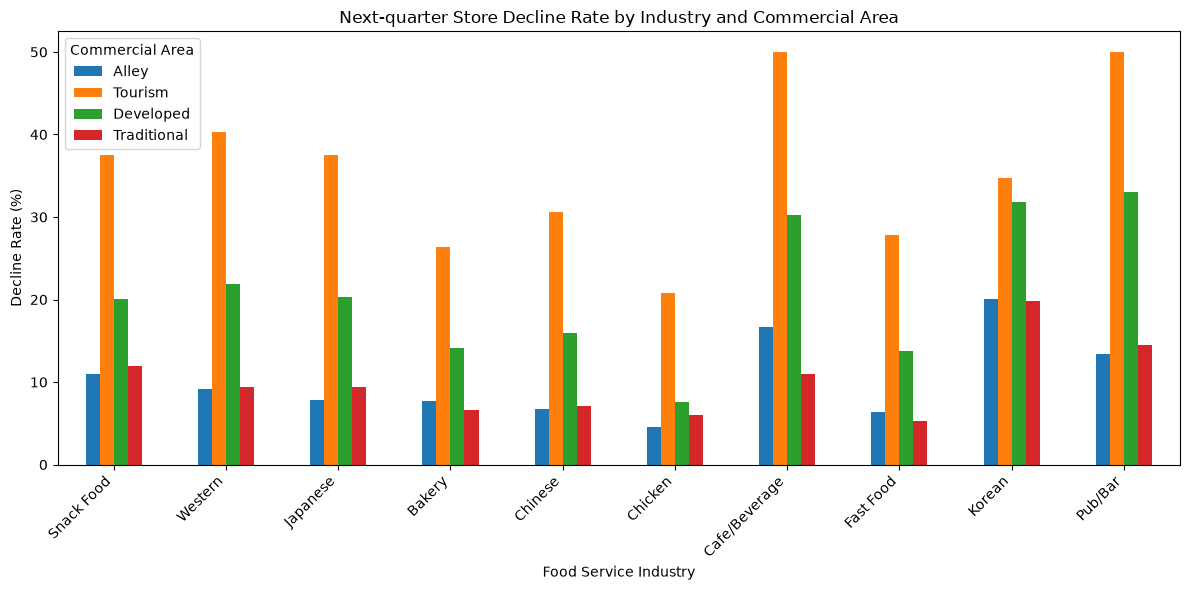

In [266]:
import matplotlib.pyplot as plt

# 업종 × 상권유형 순감소율 표
plot_data = (
    df_food
    .groupby(["서비스_업종_코드_명", "상권_구분_코드_명"])
    ["다음_분기_순감소"]
    .mean()
    .mul(100)
    .unstack()
)

# 한글 폰트 문제를 피하기 위해 그래프 표시명은 영어 사용
name_map = {
    "한식음식점": "Korean",
    "중식음식점": "Chinese",
    "일식음식점": "Japanese",
    "양식음식점": "Western",
    "제과점": "Bakery",
    "패스트푸드점": "Fast Food",
    "치킨전문점": "Chicken",
    "분식전문점": "Snack Food",
    "호프-간이주점": "Pub/Bar",
    "커피-음료": "Cafe/Beverage"
}

market_map = {
    "골목상권": "Alley",
    "관광특구": "Tourism",
    "발달상권": "Developed",
    "전통시장": "Traditional"
}

plot_data = plot_data.rename(
    index=name_map,
    columns=market_map
)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Next-quarter Store Decline Rate by Industry and Commercial Area")
ax.set_xlabel("Food Service Industry")
ax.set_ylabel("Decline Rate (%)")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Commercial Area")
plt.tight_layout()
plt.show()

### 시각화 결과

요식업 10개 업종의 상권 유형별 다음 분기 순감소율을 비교한 결과,
대부분의 업종에서 관광특구와 발달상권의 순감소율이
골목상권과 전통시장보다 높게 나타났다.

특히 커피·음료와 호프·간이주점에서 상권 유형 간 차이가 크게 나타났으며,
한식음식점은 다른 업종과 비교해 골목상권과 전통시장에서도
상대적으로 높은 순감소율을 보였다.

다만 관광특구는 다른 상권 유형에 비해 관측치가 적으므로
단순 비율의 크기만으로 해석하지 않고 통계적 검정 및 이후 모델링 결과를 함께 고려한다.

## 14. 분기별 다음 분기 순감소율 확인

상권 유형별 순감소율 차이가 특정 시기의 영향으로 나타났을 가능성을 확인하기 위해,
요식업 10개 업종의 다음 분기 순감소율을 분기별로 비교한다.

이를 통해 분석 기간 동안 순감소 위험의 시간적 변동이 존재하는지 확인하고,
이후 모델링에서 분기 효과를 고려할 필요가 있는지 판단한다.

In [267]:
분기별_순감소율 = (
    df_food
    .groupby("기준_년분기_코드")["다음_분기_순감소"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

분기별_순감소율["순감소율(%)"] = (
    분기별_순감소율["mean"] * 100
)

print(분기별_순감소율)

    기준_년분기_코드  count     sum      mean    순감소율(%)
0       20231  12315  1571.0  0.127568  12.756801
1       20232  12310  1662.0  0.135012  13.501219
2       20233  12312  1405.0  0.114116  11.411631
3       20234  12334  1533.0  0.124291  12.429058
4       20241  12325  1680.0  0.136308  13.630832
5       20242  12296  1746.0  0.141997  14.199740
6       20243  12263  1580.0  0.128843  12.884286
7       20244  12245  1777.0  0.145120  14.512046
8       20251  12236  1684.0  0.137627  13.762668
9       20252  12197  1597.0  0.130934  13.093384
10      20253  12164  1538.0  0.126439  12.643867
11      20254  12141  1573.0  0.129561  12.956099


In [268]:
분기_상권_순감소율 = (
    df_food
    .groupby([
        "기준_년분기_코드",
        "상권_구분_코드_명"
    ])["다음_분기_순감소"]
    .mean()
    .mul(100)
    .unstack()
)

print(분기_상권_순감소율.round(2))

상권_구분_코드_명   골목상권   관광특구   발달상권   전통시장
기준_년분기_코드                             
20231       11.46  11.86  18.81  10.54
20232       11.32  38.98  21.07  12.18
20233       10.05  27.12  17.18   9.28
20234       10.55  35.59  20.30   9.61
20241       11.59  38.98  21.77  11.07
20242       11.85  40.68  23.78  11.06
20243       11.09  32.20  20.50  10.10
20244       12.18  45.76  24.39  10.68
20251       11.86  31.67  20.41  12.62
20252       10.27  36.67  23.15  11.20
20253       10.65  43.33  19.11  11.65
20254       10.45  41.67  22.05  10.80


### 분기별 분석 결과

2023년 1분기부터 2025년 4분기까지 요식업의 전체 순감소율은
약 11~15% 범위에서 변동하여 특정 분기에 극단적으로 집중되는 현상은 나타나지 않았다.

상권 유형별로 분기별 순감소율을 비교한 결과,
관광특구와 발달상권의 순감소율이 상대적으로 높은 패턴이 여러 분기에 걸쳐 반복적으로 관찰되었다.

따라서 앞서 확인한 상권 유형별 차이가 특정 한두 분기의 영향만으로
발생한 것으로 보기는 어렵다.

다만 분기별 순감소율에 일정한 변동이 존재하므로,
이후 모델링에서는 분기 효과를 함께 고려한다.

## 15. 순감소 지표와 폐업 관련 지표 교차검수

본 분석에서 생성한 `다음_분기_순감소`는 분기 간 점포 수 변화를 이용한 지표이다.

따라서 해당 지표가 실제 폐업 관련 지표와도 유사한 방향성을 보이는지 확인하여,
순감소 지표의 해석이 적절한지 추가로 검수한다.

In [269]:
# 현재 데이터에 존재하는 폐업 관련 컬럼 확인
[col for col in df_all.columns if "폐업" in col]

['폐업_률', '폐업_점포_수']

In [270]:
# 요식업 10개만 대상으로 순감소 여부와 폐업 지표 비교
폐업_검수 = (
    df_food
    .groupby("다음_분기_순감소")[
        ["폐업_률", "폐업_점포_수"]
    ]
    .agg(["count", "mean", "median"])
)

print("=== 순감소 여부별 폐업 지표 ===")
print(폐업_검수)

=== 순감소 여부별 폐업 지표 ===
             폐업_률                  폐업_점포_수                 
            count      mean median   count      mean median
다음_분기_순감소                                                  
0.0        127792  4.597009    0.0  127792  0.357276    0.0
1.0         19346  4.081877    0.0   19346  0.956839    0.0


In [271]:
[col for col in df_all.columns if "개업" in col]

['개업_율', '개업_점포_수']

In [272]:
# 순감소 여부별 개업·폐업 지표 비교
개폐업_검수 = (
    df_food
    .groupby("다음_분기_순감소")[
        ["개업_율", "폐업_률", "개업_점포_수", "폐업_점포_수"]
    ]
    .agg(["mean", "median"])
)

print("=== 순감소 여부별 개업·폐업 비교 ===")
print(개폐업_검수)

=== 순감소 여부별 개업·폐업 비교 ===
               개업_율             폐업_률          개업_점포_수          폐업_점포_수       
               mean median      mean median      mean median      mean median
다음_분기_순감소                                                                    
0.0        3.701124    0.0  4.597009    0.0  0.343809    0.0  0.357276    0.0
1.0        4.303215    0.0  4.081877    0.0  0.960302    0.0  0.956839    0.0


In [273]:
# 개업점포 수와 폐업점포 수의 차이
df_food["개폐업_점포차"] = (
    df_food["개업_점포_수"] - df_food["폐업_점포_수"]
)

print("=== 순감소 여부별 개업 - 폐업 점포 차이 ===")
print(
    df_food
    .groupby("다음_분기_순감소")["개폐업_점포차"]
    .agg(["count", "mean", "median"])
)

=== 순감소 여부별 개업 - 폐업 점포 차이 ===
            count      mean  median
다음_분기_순감소                          
0.0        127792 -0.013467     0.0
1.0         19346  0.003463     0.0


In [274]:
# 다음 분기의 개업·폐업 지표 붙이기
next_open_close = df_all[
    [
        "기준_년분기_코드",
        "상권_코드",
        "서비스_업종_코드",
        "개업_율",
        "폐업_률",
        "개업_점포_수",
        "폐업_점포_수"
    ]
].copy()

# 다음 분기 데이터임을 구분하기 위해 컬럼명 변경
next_open_close = next_open_close.rename(columns={
    "기준_년분기_코드": "다음_분기_코드",
    "개업_율": "다음_분기_개업_율",
    "폐업_률": "다음_분기_폐업_률",
    "개업_점포_수": "다음_분기_개업_점포_수",
    "폐업_점포_수": "다음_분기_폐업_점포_수"
})

# 현재 행에 실제 다음 분기의 개·폐업 정보 연결
df_food_check = df_food.merge(
    next_open_close,
    on=[
        "다음_분기_코드",
        "상권_코드",
        "서비스_업종_코드"
    ],
    how="left"
)

print("원래 df_food:", len(df_food))
print("병합 후:", len(df_food_check))

print("\n다음 분기 폐업정보 결측:")
print(df_food_check["다음_분기_폐업_점포_수"].isna().sum())

원래 df_food: 147138
병합 후: 147138

다음 분기 폐업정보 결측:
0


In [275]:
# 다음 분기 개업·폐업 점포 수 차이
df_food_check["다음_분기_개폐업_점포차"] = (
    df_food_check["다음_분기_개업_점포_수"]
    - df_food_check["다음_분기_폐업_점포_수"]
)

# 순감소 여부별 다음 분기 개·폐업 지표 비교
다음분기_개폐업_검수 = (
    df_food_check
    .groupby("다음_분기_순감소")[
        [
            "다음_분기_개업_율",
            "다음_분기_폐업_률",
            "다음_분기_개업_점포_수",
            "다음_분기_폐업_점포_수",
            "다음_분기_개폐업_점포차"
        ]
    ]
    .agg(["mean", "median"])
)

print("=== 순감소 여부별 '다음 분기' 개업·폐업 비교 ===")
print(다음분기_개폐업_검수)

=== 순감소 여부별 '다음 분기' 개업·폐업 비교 ===
          다음_분기_개업_율        다음_분기_폐업_률        다음_분기_개업_점포_수         \
                mean median       mean median          mean median   
다음_분기_순감소                                                            
0.0         3.260791    0.0   1.861838    0.0      0.385932    0.0   
1.0         2.082860    0.0  21.826527   12.0      0.557531    0.0   

          다음_분기_폐업_점포_수        다음_분기_개폐업_점포차         
                   mean median          mean median  
다음_분기_순감소                                            
0.0            0.214880    0.0      0.171051    0.0  
1.0            1.932648    1.0     -1.375116   -1.0  


### 순감소 지표 교차검수 결과

처음에는 현재 분기의 개·폐업 지표와 다음 분기 순감소 여부를 비교하였으나,
두 지표의 시간 기준이 일치하지 않아 뚜렷한 관계를 확인하기 어려웠다.

이에 현재 분기의 점포 수에서 다음 분기 점포 수로의 순감소 여부와
실제 다음 분기의 개·폐업 지표를 연결하여 다시 비교하였다.

그 결과 순감소가 발생하지 않은 집단의 다음 분기 평균 폐업률은 약 1.86%,
평균 개업-폐업 점포 차이는 +0.17개로 나타났다.

반면 순감소가 발생한 집단에서는 다음 분기 평균 폐업률이 약 21.83%로 높았으며,
평균 개업-폐업 점포 차이는 -1.38개, 중앙값은 -1개로 나타났다.

따라서 본 분석에서 생성한 `다음_분기_순감소` 지표는
실제 다음 분기의 개·폐업 흐름과 일관된 방향성을 보이는 것으로 확인되었다.

다만 순감소는 개별 사업체의 폐업 여부가 아니라
상권 내 전체 점포 수의 순변화를 의미하므로,
이후 분석에서는 이를 '폐업 여부'와 동일한 개념으로 해석하지 않고
'다음 분기 점포 순감소 위험'으로 구분하여 사용한다.

## 16. 자치구·업종·분기를 고려한 로지스틱 회귀

앞선 분석에서 상권 유형과 다음 분기 점포 순감소 여부 사이에
통계적으로 유의한 관련성이 있음을 확인하였다.

이번에는 자치구, 업종, 분기 등의 차이를 함께 고려한 상태에서도
상권 유형과 다음 분기 점포 순감소 위험의 관계가 유지되는지
로지스틱 회귀를 통해 확인한다.

- 종속변수(Y): 다음_분기_순감소 (0/1)
- 주요 설명변수: 상권 유형
- 통제변수: 자치구, 서비스 업종, 기준 분기

In [276]:
import statsmodels.formula.api as smf

# 로지스틱 회귀용 데이터
logit_df = df_food[
    [
        "다음_분기_순감소",
        "상권_구분_코드_명",
        "자치구_코드_명",
        "서비스_업종_코드_명",
        "기준_년분기_코드"
    ]
].dropna().copy()

# 분기 코드를 범주형으로 처리
logit_df["기준_년분기_코드"] = (
    logit_df["기준_년분기_코드"].astype(str)
)

print("모델링 데이터 수:", len(logit_df))
print("Y 분포:")
print(logit_df["다음_분기_순감소"].value_counts())

모델링 데이터 수: 147138
Y 분포:
다음_분기_순감소
0.0    127792
1.0     19346
Name: count, dtype: int64


In [277]:
# 자치구·업종·분기를 통제한 로지스틱 회귀

logit_model = smf.logit(
    formula="""
        다음_분기_순감소
        ~ C(상권_구분_코드_명)
        + C(자치구_코드_명)
        + C(서비스_업종_코드_명)
        + C(기준_년분기_코드)
    """,
    data=logit_df
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.367767
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              다음_분기_순감소   No. Observations:               147138
Model:                          Logit   Df Residuals:                   147090
Method:                           MLE   Df Model:                           47
Date:                Fri, 21 Aug 2026   Pseudo R-squ.:                 0.05506
Time:                        17:35:39   Log-Likelihood:                -54112.
converged:                       True   LL-Null:                       -57265.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -2.2130      0.047    -47.078      0.000      -2.

In [278]:
# 상권유형 관련 회귀 결과만 확인
result = logit_model.summary2().tables[1]

상권_결과 = result[
    result.index.str.contains("상권_구분_코드_명")
]

print(상권_결과)

                          Coef.  Std.Err.          z         P>|z|    [0.025  \
C(상권_구분_코드_명)[T.관광특구]  1.702675  0.083352  20.427445  9.536250e-93  1.539307   
C(상권_구분_코드_명)[T.발달상권]  0.905282  0.019479  46.475584  0.000000e+00  0.867105   
C(상권_구분_코드_명)[T.전통시장] -0.031572  0.023956  -1.317889  1.875408e-01 -0.078526   

                         0.975]  
C(상권_구분_코드_명)[T.관광특구]  1.866042  
C(상권_구분_코드_명)[T.발달상권]  0.943459  
C(상권_구분_코드_명)[T.전통시장]  0.015382  


In [279]:
import numpy as np

상권_결과 = 상권_결과.copy()

상권_결과["Odds Ratio"] = np.exp(상권_결과["Coef."])
상권_결과["OR 2.5%"] = np.exp(상권_결과["[0.025"])
상권_결과["OR 97.5%"] = np.exp(상권_결과["0.975]"])

print(
    상권_결과[
        ["Coef.", "P>|z|", "Odds Ratio", "OR 2.5%", "OR 97.5%"]
    ].round(4)
)

                        Coef.   P>|z|  Odds Ratio  OR 2.5%  OR 97.5%
C(상권_구분_코드_명)[T.관광특구]  1.7027  0.0000      5.4886   4.6614    6.4627
C(상권_구분_코드_명)[T.발달상권]  0.9053  0.0000      2.4726   2.3800    2.5689
C(상권_구분_코드_명)[T.전통시장] -0.0316  0.1875      0.9689   0.9245    1.0155


### 로지스틱 회귀 결과

자치구, 요식업 업종, 분기의 차이를 함께 고려한 로지스틱 회귀 결과,
상권 유형에 따른 다음 분기 점포 순감소 위험의 차이가 확인되었다.

골목상권을 기준으로 관광특구의 순감소 오즈는 약 5.49배
(OR=5.49, 95% CI: 4.66~6.46, p<0.001),
발달상권은 약 2.47배
(OR=2.47, 95% CI: 2.38~2.57, p<0.001) 높게 나타났다.

반면 전통시장은 골목상권 대비 오즈비가 약 0.97이었으며,
통계적으로 유의한 차이는 확인되지 않았다
(OR=0.97, 95% CI: 0.92~1.02, p=0.188).

따라서 자치구, 업종, 분기의 차이를 고려한 이후에도
관광특구와 발달상권에서 상대적으로 높은 순감소 위험이 관찰되었다.

다만 본 결과는 변수 간 관련성을 나타내는 것으로,
상권 유형이 점포 순감소의 직접적인 원인임을 의미하지 않는다.